In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier as GBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pickle
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import  TimeSeriesSplit


In [4]:
data = pd.read_csv('../datasets/EURUSD_M1_data.csv')

In [29]:
df = pd.DataFrame(data)
df.head()

,time,open,high,low,close,tick_volume
0,2024-11-29 00:00:00,1.05477,1.05477,1.05477,1.05477,1
1,2024-11-29 00:01:00,1.05477,1.05525,1.05469,1.05469,4
2,2024-11-29 00:03:00,1.05469,1.05469,1.05469,1.05469,1
3,2024-11-29 00:04:00,1.05477,1.05478,1.05469,1.05469,3
4,2024-11-29 00:05:00,1.05464,1.05516,1.05464,1.05490,7


In [30]:
df.shape

(895, 6)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         895 non-null    object 
 1   open         895 non-null    float64
 2   high         895 non-null    float64
 3   low          895 non-null    float64
 4   close        895 non-null    float64
 5   tick_volume  895 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 42.1+ KB


In [32]:
df.isnull().sum() #to check null values

time           0
open           0
high           0
low            0
close          0
tick_volume    0
dtype: int64

In [33]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
890    False
891    False
892    False
893    False
894    False
Length: 895, dtype: bool

In [34]:
def detect_outliers(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        # Drop NaN values for this calculation
        col_data = df[column].dropna()

        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers[column] = col_data[(col_data < lower_bound) | (col_data > upper_bound)]

    return outliers

outliers_found = detect_outliers(df)

# Display the results
for column, outliers in outliers_found.items():
    print(f"Outliers in {column}:")
    print(outliers)
    print("\n")


Outliers in open:
564    1.05887
565    1.05890
566    1.05921
567    1.05924
568    1.05935
569    1.05950
570    1.05908
571    1.05898
572    1.05891
Name: open, dtype: float64


Outliers in high:
563    1.05888
564    1.05897
565    1.05932
566    1.05928
567    1.05936
568    1.05970
569    1.05950
570    1.05924
571    1.05902
572    1.05891
Name: high, dtype: float64


Outliers in low:
563    1.05874
564    1.05886
565    1.05890
566    1.05910
567    1.05917
568    1.05935
569    1.05911
Name: low, dtype: float64


Outliers in close:
563    1.05888
564    1.05891
565    1.05921
566    1.05924
567    1.05935
568    1.05950
569    1.05911
570    1.05898
571    1.05892
Name: close, dtype: float64


Outliers in tick_volume:
584     79
663    101
Name: tick_volume, dtype: int64




In [35]:
# Duplicate the column
df['Adj Close'] = df['close']
df

,time,open,high,low,close,tick_volume,Adj Close
0,2024-11-29 00:00:00,1.05477,1.05477,1.05477,1.05477,1,1.05477
1,2024-11-29 00:01:00,1.05477,1.05525,1.05469,1.05469,4,1.05469
2,2024-11-29 00:03:00,1.05469,1.05469,1.05469,1.05469,1,1.05469
3,2024-11-29 00:04:00,1.05477,1.05478,1.05469,1.05469,3,1.05469
4,2024-11-29 00:05:00,1.05464,1.05516,1.05464,1.05490,7,1.05490
...,...,...,...,...,...,...,...
890,2024-11-29 14:51:00,1.05514,1.05519,1.05502,1.05509,45,1.05509
891,2024-11-29 14:52:00,1.05509,1.05524,1.05499,1.05518,36,1.05518
892,2024-11-29 14:53:00,1.05519,1.05534,1.05509,1.05534,50,1.05534
893,2024-11-29 14:54:00,1.05532,1.05542,1.05525,1.05527,51,1.05527


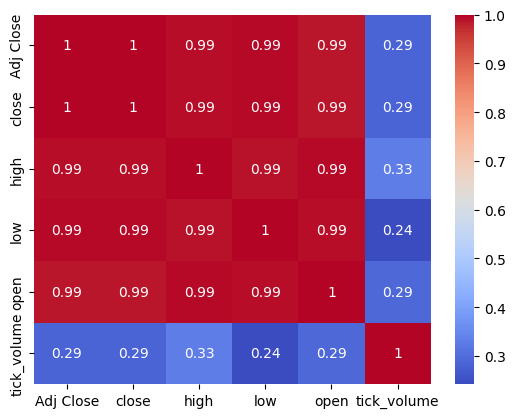

In [36]:
corr_matrix = df[['Adj Close', 'close', 'high', 'low', 'open', 'tick_volume']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [37]:
df.describe()

,open,high,low,close,tick_volume,Adj Close
count,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000
mean,1.056622,1.056704,1.056537,1.056624,30.387709,1.056624
std,0.000844,0.000845,0.000839,0.000844,15.287640,0.000844
min,1.054640,1.054690,1.054640,1.054690,1.000000,1.054690
25%,1.056020,1.056100,1.055960,1.056025,19.000000,1.056025
50%,1.056750,1.056830,1.056690,1.056750,29.000000,1.056750
75%,1.057140,1.057200,1.057060,1.057140,42.000000,1.057140
max,1.059500,1.059700,1.059350,1.059500,101.000000,1.059500


In [38]:
df.columns

Index(['time', 'open', 'high', 'low', 'close', 'tick_volume', 'Adj Close'], dtype='object')

## Feature engineering

In [40]:
# Calculate 50-day and 200-day SMA and EMA
df['SMA50'] = df['close'].rolling(window=50).mean()
df['SMA200'] = df['close'].rolling(window=200).mean()

# Check results
print("SMA50:", df['SMA50'].head(60))  # Display first 60 rowsa

# Check for empty or NaN values in SMA
print("SMA50 NaN counts:", df['SMA50'].isna().sum())

# Calculate EMA (50 and 200-day)
df['EMA50'] = df['close'].ewm(span=50, adjust=False).mean()
df['EMA200'] = df['close'].ewm(span=200, adjust=False).mean()

# Check results for EMA
print("EMA50:", df['EMA50'].head(60))  # Display first 60 rows

# Check for empty or NaN values in EMA
print("EMA50 NaN counts:", df['EMA50'].isna().sum())


SMA50: 0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24         NaN
25         NaN
26         NaN
27         NaN
28         NaN
29         NaN
30         NaN
31         NaN
32         NaN
33         NaN
34         NaN
35         NaN
36         NaN
37         NaN
38         NaN
39         NaN
40         NaN
41         NaN
42         NaN
43         NaN
44         NaN
45         NaN
46         NaN
47         NaN
48         NaN
49    1.055164
50    1.055178
51    1.055194
52    1.055209
53    1.055224
54    1.055229
55    1.055231
56    1.055231
57    1.055233
58    1.055234
59    1.055244
Name: SMA50, dtype: float64
SMA50 NaN counts: 49
EMA50: 0     1.054770
1     1.054767
2     1

In [41]:
df.head()

,time,open,high,low,close,tick_volume,Adj Close,SMA50,SMA200,EMA50,EMA200
0,2024-11-29 00:00:00,1.05477,1.05477,1.05477,1.05477,1,1.05477,NaN,NaN,1.054770,1.054770
1,2024-11-29 00:01:00,1.05477,1.05525,1.05469,1.05469,4,1.05469,NaN,NaN,1.054767,1.054769
2,2024-11-29 00:03:00,1.05469,1.05469,1.05469,1.05469,1,1.05469,NaN,NaN,1.054764,1.054768
3,2024-11-29 00:04:00,1.05477,1.05478,1.05469,1.05469,3,1.05469,NaN,NaN,1.054761,1.054768
4,2024-11-29 00:05:00,1.05464,1.05516,1.05464,1.05490,7,1.05490,NaN,NaN,1.054766,1.054769


In [44]:
df.isnull().sum() #to check null values

time             0
open             0
high             0
low              0
close            0
tick_volume      0
Adj Close        0
SMA50            0
SMA200         150
EMA50            0
EMA200           0
dtype: int64

In [43]:
df.dropna(subset=['SMA50'], inplace=True)


In [45]:
df.dropna(subset=['SMA200'], inplace=True)


In [46]:
df.describe()

,open,high,low,close,tick_volume,Adj Close,SMA50,SMA200,EMA50,EMA200
count,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000,696.000000
mean,1.056840,1.056926,1.056750,1.056839,33.862069,1.056839,1.056887,1.056887,1.056879,1.056830
std,0.000778,0.000775,0.000779,0.000782,13.628407,0.000782,0.000624,0.000468,0.000613,0.000451
min,1.054880,1.055040,1.054810,1.054870,6.000000,1.054870,1.055437,1.055875,1.055431,1.055974
25%,1.056342,1.056400,1.056198,1.056337,23.000000,1.056337,1.056363,1.056519,1.056374,1.056481
50%,1.056900,1.056950,1.056840,1.056900,33.000000,1.056900,1.056973,1.056924,1.056941,1.056883
75%,1.057250,1.057330,1.057180,1.057253,44.000000,1.057253,1.057146,1.057282,1.057195,1.057117
max,1.059500,1.059700,1.059350,1.059500,101.000000,1.059500,1.058465,1.057583,1.058353,1.057682


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 199 to 894
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         696 non-null    object 
 1   open         696 non-null    float64
 2   high         696 non-null    float64
 3   low          696 non-null    float64
 4   close        696 non-null    float64
 5   tick_volume  696 non-null    int64  
 6   Adj Close    696 non-null    float64
 7   SMA50        696 non-null    float64
 8   SMA200       696 non-null    float64
 9   EMA50        696 non-null    float64
 10  EMA200       696 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 65.2+ KB


In [48]:
df.loc[:, 'SMA_5'] = df['close'].rolling(window=5).mean()
df.loc[:, 'SMA_10'] = df['close'].rolling(window=10).mean()
df.loc[:, 'SMA_20'] = df['close'].rolling(window=20).mean()

df.loc[:, 'EMA_5'] = df['close'].ewm(span=5, adjust=False).mean()
df.loc[:, 'EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()

df.loc[:, 'ROC_5'] = df['close'].pct_change(periods=5)
df.loc[:, 'Price_Change'] = df['close'].pct_change()
df.loc[:, 'Lag_1'] = df['close'].shift(1)
df.loc[:, 'Volatility_5'] = df['close'].rolling(window=5).std()
df.loc[:, 'Cumulative_Returns'] = (1 + df['Price_Change']).cumprod() - 1
df.loc[:, 'Volume_SMA_7'] = df['tick_volume'].rolling(window=7).mean()

df = df.dropna()

X = df[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change', 'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7']]
y = df['close']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [50]:
# Prepare feature set and target variable
X = df[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change',
          'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7']]
y = df['close']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the model
svm_model = SVR()

# Define hyperparameters to search
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernels to try
    'C': [0.1, 1, 10, 100],               # Regularization strength
    'gamma': ['scale', 'auto', 0.01, 0.1] # Gamma values
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
print("Best Parameters: ", grid_search.best_params_)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Now that the model is fitted, predict on the test set
y_pred = best_model.predict(X_test)

# Evaluate the optimized model
mse = mean_squared_error(y_test, y_pred)
# Use best_model instead of svm_model for calculating the score
r2 = best_model.score(X_test, y_test)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mean Squared Error: 7.498852941176433e-07
R^2 Score: -0.09399014753457902


In [51]:

# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Predicting on training data
y_train_pred = best_model.predict(X_train)  # Changed from svm_model to best_model
train_mse = mean_squared_error(y_train, y_train_pred)

# Predicting on testing data
y_test_pred = best_model.predict(X_test)  # Changed from svm_model to best_model
test_mse = mean_squared_error(y_test, y_test_pred)

print(f'Training MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Training MSE: 6.86303512014787e-07
Test MSE: 7.498852941176433e-07


In [52]:
data = df

In [54]:
svm_model.fit(X_train, y_train)

X_scaled_full = scaler.transform(data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change',
                                      'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7']])
data['SVM_Prediction'] = svm_model.predict(X_scaled_full)

# Default signal
data['Signal'] = 0

# Generate Buy signal: SMA_5 > SMA_20 and SVM Prediction indicates an upward trend
data.loc[(data['SMA_5'] > data['SMA_20']) & (data['SVM_Prediction'] > data['SVM_Prediction'].shift(1)), 'Signal'] = 1

# Generate Sell signal: SMA_5 < SMA_20 and SVM Prediction indicates a downward trend
data.loc[(data['SMA_5'] < data['SMA_20']) & (data['SVM_Prediction'] < data['SVM_Prediction'].shift(1)), 'Signal'] = -1

# Add signal changes (Position)
data['Position'] = data['Signal'].diff()

# Print generated signals
print(data[['close', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change',
            'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7', 'Signal', 'Position', 'SVM_Prediction']].tail())


       close     SMA_5    SMA_10    SMA_20     EMA_5    EMA_10     ROC_5  \
890  1.05509  1.055028  1.055146  1.055257  1.055084  1.055133 -0.000142   
891  1.05518  1.055058  1.055128  1.055263  1.055116  1.055142  0.000142   
892  1.05534  1.055152  1.055120  1.055271  1.055191  1.055178  0.000446   
893  1.05527  1.055206  1.055119  1.055266  1.055217  1.055195  0.000256   
894  1.05529  1.055234  1.055146  1.055251  1.055241  1.055212  0.000133   

     Price_Change    Lag_1  Volatility_5  Cumulative_Returns  Volume_SMA_7  \
890     -0.000057  1.05515      0.000105           -0.001571     38.142857   
891      0.000085  1.05509      0.000126           -0.001486     37.428571   
892      0.000152  1.05518      0.000126           -0.001334     39.571429   
893     -0.000066  1.05534      0.000099           -0.001401     42.000000   
894      0.000019  1.05527      0.000099           -0.001382     43.714286   

     Signal  Position  SVM_Prediction  
890       0       0.0         1.05

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\1643224475.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SVM_Prediction'] = svm_model.predict(X_scaled_full)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\1643224475.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'] = 0
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\1643224475.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [55]:
feature_names = scaler.get_feature_names_out()
print(feature_names)

['SMA_5' 'SMA_10' 'SMA_20' 'EMA_5' 'EMA_10' 'ROC_5' 'Price_Change' 'Lag_1'
 'Volatility_5' 'Cumulative_Returns' 'Volume_SMA_7']


In [57]:
data['Predicted_Close'] = svm_model.predict(scaler.transform(X))
data['Predicted_Signal'] = 0
data.loc[data['Predicted_Close'] > data['close'].shift(1), 'Predicted_Signal'] = 1
data.loc[data['Predicted_Close'] < data['close'].shift(1), 'Predicted_Signal'] = -1
data['Predicted_Position'] = data['Predicted_Signal'].diff()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2539304291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Predicted_Close'] = svm_model.predict(scaler.transform(X))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2539304291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Predicted_Signal'] = 0
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2539304291.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

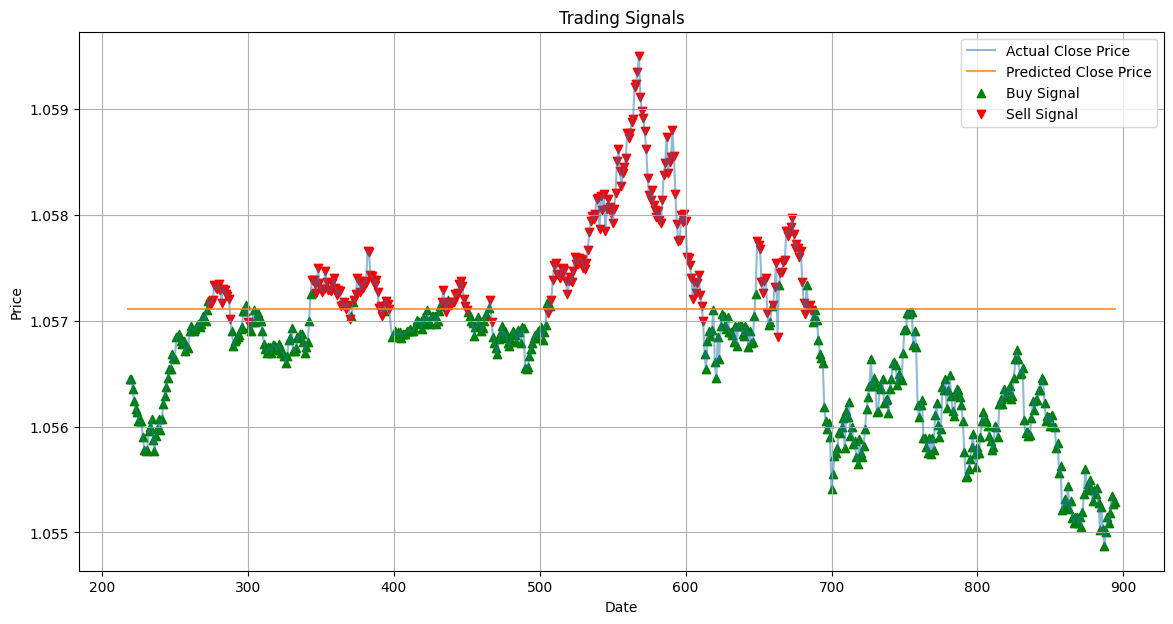

In [59]:
# Visualize Buy/Sell Signals
plt.figure(figsize=(14, 7))
plt.plot(data['close'], label='Actual Close Price', alpha=0.5)
plt.plot(data['Predicted_Close'], label='Predicted Close Price', alpha=0.75)
plt.scatter(data.index[data['Predicted_Signal'] == 1], data['close'][data['Predicted_Signal'] == 1],
            label='Buy Signal', marker='^', color='green')
plt.scatter(data.index[data['Predicted_Signal'] == -1], data['close'][data['Predicted_Signal'] == -1],
            label='Sell Signal', marker='v', color='red')
plt.title('Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [61]:
available_capital = 100000
risk_per_trade = 0.10  # 10% of capital per trade
capital_per_trade = available_capital * risk_per_trade

# Set stop-loss and take-profit thresholds (as percentage of the asset's price)
stop_loss_percentage = 0.02  # 2% stop-loss
take_profit_percentage = 0.05  # 5% take-profit

# Initialize position size to 0.02
data['Position_Size'] = 0.02

# Position size for Buy signals
data.loc[data['Signal'] == 1, 'Position_Size'] = capital_per_trade / data['close']

# For Sell signals, position size is negative (opposite of Buy)
data.loc[data['Signal'] == -1, 'Position_Size'] = -capital_per_trade / data['close']

# Integrate SVM predictions: Use a threshold to only take significant trades based on SVM predictions
threshold = 0.01  # Only take trades when SVM predicts a significant change (1%)

# Adjust position size for Buy signals if SVM prediction is positive and above threshold
data.loc[(data['Signal'] == 1) &
          (data['SVM_Prediction'] > data['SVM_Prediction'].shift(1)) &
          (data['SVM_Prediction'].pct_change() > threshold), 'Position_Size'] = capital_per_trade / data['close']

# Adjust position size for Sell signals if SVM prediction is negative and below threshold
data.loc[(data['Signal'] == -1) &
          (data['SVM_Prediction'] < data['SVM_Prediction'].shift(1)) &
          (data['SVM_Prediction'].pct_change() < -threshold), 'Position_Size'] = -capital_per_trade / data['close']

# Implement risk management: Set stop-loss and take-profit levels based on price change
data['Stop_Loss'] = data['close'] * (1 - stop_loss_percentage)
data['Take_Profit'] = data['close'] * (1 + take_profit_percentage)

# Simulate trade exits based on stop-loss or take-profit conditions
data['Exit'] = 0  # Default no exit
data.loc[data['close'] <= data['Stop_Loss'], 'Exit'] = -1  # Exit if price hits stop-loss (sell)
data.loc[data['close'] >= data['Take_Profit'], 'Exit'] = 1  # Exit if price hits take-profit (sell)

print(data[['close', 'Signal', 'Position_Size', 'SVM_Prediction', 'Stop_Loss', 'Take_Profit', 'Exit']].tail())


       close  Signal  Position_Size  SVM_Prediction  Stop_Loss  Take_Profit  \
890  1.05509       0           0.02         1.05711   1.033988     1.107845   
891  1.05518       0           0.02         1.05711   1.034076     1.107939   
892  1.05534       0           0.02         1.05711   1.034233     1.108107   
893  1.05527       0           0.02         1.05711   1.034165     1.108033   
894  1.05529       0           0.02         1.05711   1.034184     1.108055   

     Exit  
890     0  
891     0  
892     0  
893     0  
894     0  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2082899205.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Position_Size'] = 0.02
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2082899205.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Stop_Loss'] = data['close'] * (1 - stop_loss_percentage)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2082899205.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\1833025276.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10000.100178160214' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)


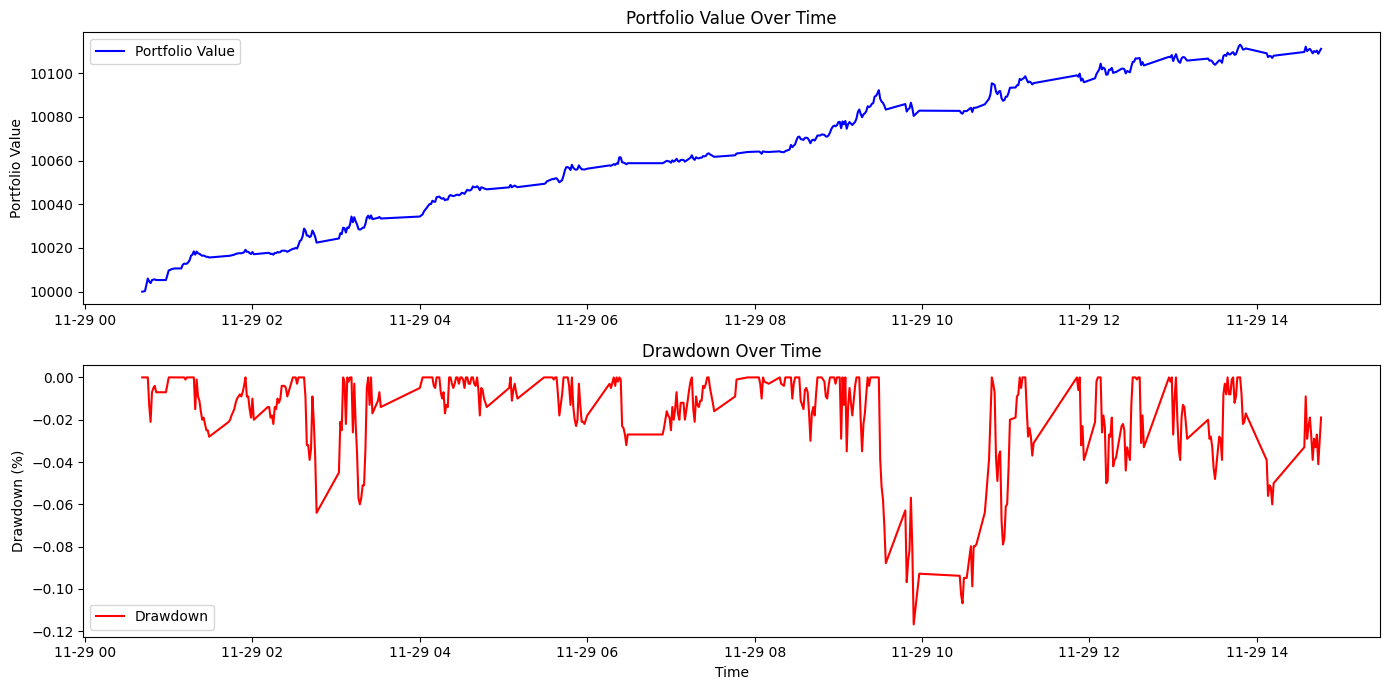

Maximum Drawdown: -0.12%
The maximum drawdown of -0.12% is within the acceptable range.


In [74]:

# Initial capital
initial_capital = 10000  # Starting portfolio value

# Calculate Returns from Close price
data['Returns'] = data['close'].pct_change()

# Initialize Portfolio Value column with initial capital
data['Portfolio_Value'] = initial_capital

# Loop through the signals and update portfolio value
# for i in range(1, len(data)):
#     if data['Signal'].iloc[i] == 1:  # Buy signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 + data['Returns'].iloc[i])
#     elif data['Signal'].iloc[i] == -1:  # Sell signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 - data['Returns'].iloc[i])
#     else:  # Hold position
        # data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1]

for i in range(1, len(data)):
    prev_value = data['Portfolio_Value'].iloc[i - 1]
    strategy_return = data['Strategy_Returns'].iloc[i]
    data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)

# Calculate Drawdown
data['Peak'] = data['Portfolio_Value'].cummax()  # Track running maximum portfolio value
data['Drawdown'] = (data['Portfolio_Value'] - data['Peak']) / data['Peak'] * 100  # Calculate drawdown as a percentage

# Plot portfolio performance and drawdown
plt.figure(figsize=(14, 7))

# Plot portfolio value over time
plt.subplot(2, 1, 1)
plt.plot(data['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.title('Portfolio Value Over Time')
plt.ylabel('Portfolio Value')
plt.legend()

# Plot drawdown over time
plt.subplot(2, 1, 2)
plt.plot(data['Drawdown'], label='Drawdown', color='red')
plt.title('Drawdown Over Time')
plt.ylabel('Drawdown (%)')
plt.xlabel('Time')
plt.legend()

# Layout adjustment and display
plt.tight_layout()
plt.show()

# Maximum drawdown
max_drawdown = data['Drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Define acceptable drawdown threshold (you can adjust this value)
acceptable_drawdown_threshold = -6.0  # -6 is the maximum drawdown, i mean we are not settling for less

# Evaluate whether the drawdown is acceptable
if max_drawdown < acceptable_drawdown_threshold:
    print(f"The maximum drawdown of {max_drawdown:.2f}% exceeds the acceptable threshold of {acceptable_drawdown_threshold}%")
    print("Consider re-evaluating the portfolio strategy.")
else:
    print(f"The maximum drawdown of {max_drawdown:.2f}% is within the acceptable range.")


In [73]:
data.head()

,open,high,low,close,Returns,SMA_5,SMA_10,SMA_20,EMA_5,EMA_10,...,Signal,MA_Signal,Final_Signal,Strategy_Returns,Portfolio_Value,Drawdown,RSI,Predicted_Signal,Cumulative_Returns_Strategy,Peak
time,,,,,,,,,,,,,,,,,,,,,
2024-11-29 00:41:00,1.05518,1.05524,1.05493,1.05523,NaN,1.055220,1.055229,1.055252,1.055220,1.055230,...,1.05711,-1,-1.05711,NaN,10000,0.0,50.0,1.05711,NaN,10000
2024-11-29 00:42:00,1.05524,1.05525,1.05523,1.05524,0.000009,1.055222,1.055237,1.055241,1.055227,1.055232,...,1.05711,-1,-1.05711,0.000010,10000,0.0,50.0,1.05711,1.000010,10000
2024-11-29 00:43:00,1.05525,1.05526,1.05525,1.05526,0.000019,1.055228,1.055243,1.055234,1.055238,1.055237,...,1.05711,-1,-1.05711,0.000020,10000,0.0,50.0,1.05711,1.000030,10000
2024-11-29 00:45:00,1.05525,1.05553,1.05525,1.05553,0.000256,1.055244,1.055240,1.055217,1.055274,1.055249,...,1.05711,1,1.05711,0.000571,10000,0.0,50.0,1.05711,1.000601,10000
2024-11-29 00:46:00,1.05542,1.05553,1.05540,1.05540,-0.000123,1.055278,1.055249,1.055215,1.055316,1.055276,...,1.05711,1,1.05711,-0.000130,10000,0.0,50.0,1.05711,1.000471,10000


In [72]:
print(data[['Signal', 'close']].head(10))


                      Signal    close
time                                 
2024-11-29 00:41:00  1.05711  1.05523
2024-11-29 00:42:00  1.05711  1.05524
2024-11-29 00:43:00  1.05711  1.05526
2024-11-29 00:45:00  1.05711  1.05553
2024-11-29 00:46:00  1.05711  1.05540
2024-11-29 00:47:00  1.05711  1.05532
2024-11-29 00:48:00  1.05711  1.05546
2024-11-29 00:49:00  1.05711  1.05548
2024-11-29 00:50:00  1.05711  1.05549
2024-11-29 00:51:00  1.05711  1.05546


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\3729878890.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '100001.00178160214' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)


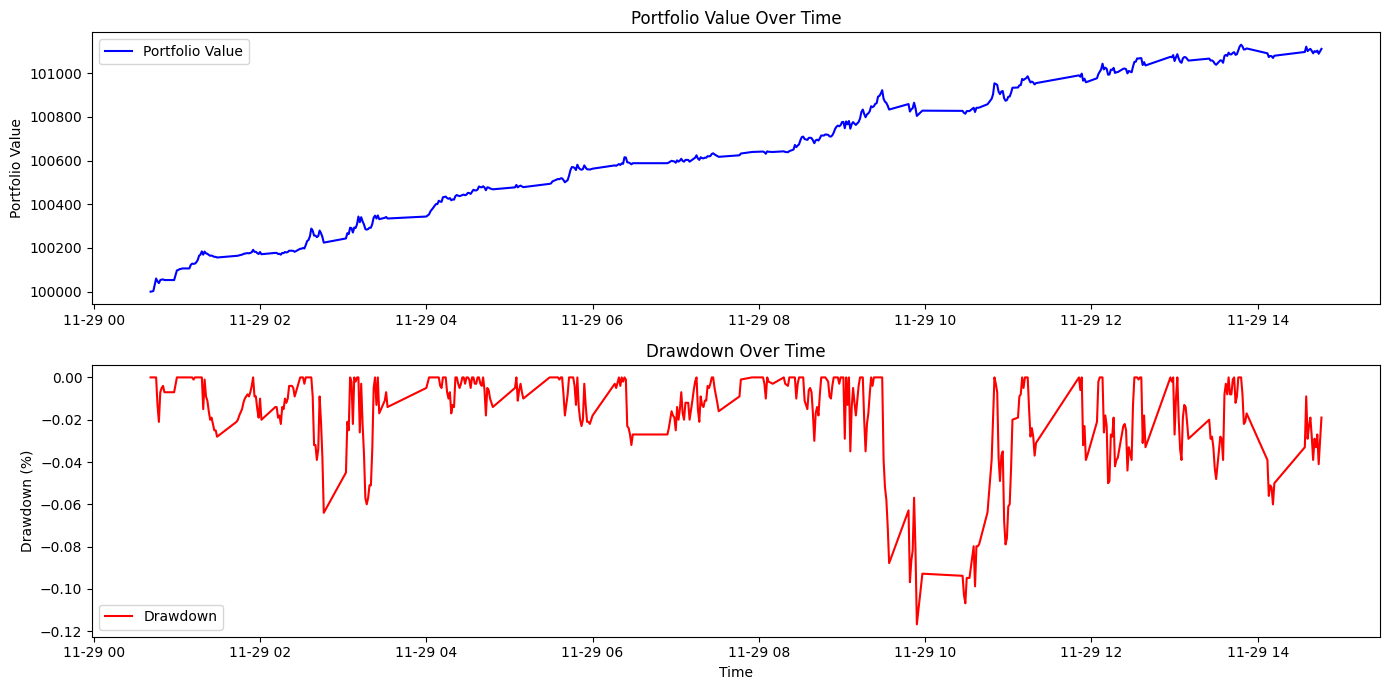

Maximum Drawdown: -0.12%
The maximum drawdown of -0.12% is within the acceptable range.


In [75]:

initial_capital = 100000  # Starting portfolio value

# Calculate Returns from Close price
data['Returns'] = data['close'].pct_change()

# Initialize Portfolio Value column with initial capital
data['Portfolio_Value'] = initial_capital

# Loop through the signals and update portfolio value
# for i in range(1, len(data)):
#     if data['Signal'].iloc[i] == 1:  # Buy signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 + data['Returns'].iloc[i])
#     elif data['Signal'].iloc[i] == -1:  # Sell signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 - data['Returns'].iloc[i])
#     else:  # Hold position
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1]

for i in range(1, len(data)):
    prev_value = data['Portfolio_Value'].iloc[i - 1]
    strategy_return = data['Strategy_Returns'].iloc[i]
    data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)

# Calculate Drawdown
data['Peak'] = data['Portfolio_Value'].cummax()  # Track running maximum portfolio value
data['Drawdown'] = (data['Portfolio_Value'] - data['Peak']) / data['Peak'] * 100  # Calculate drawdown as a percentage

# Plot portfolio performance and drawdown
plt.figure(figsize=(14, 7))

# Plot portfolio value over time
plt.subplot(2, 1, 1)
plt.plot(data['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.title('Portfolio Value Over Time')
plt.ylabel('Portfolio Value')
plt.legend()

# Plot drawdown over time
plt.subplot(2, 1, 2)
plt.plot(data['Drawdown'], label='Drawdown', color='red')
plt.title('Drawdown Over Time')
plt.ylabel('Drawdown (%)')
plt.xlabel('Time')
plt.legend()

# Layout adjustment and display
plt.tight_layout()
plt.show()

# Maximum drawdown
max_drawdown = data['Drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Define acceptable drawdown threshold (you can adjust this value)
acceptable_drawdown_threshold = -6.0

# Evaluate whether the drawdown is acceptable
if max_drawdown < acceptable_drawdown_threshold:
    print(f"The maximum drawdown of {max_drawdown:.2f}% exceeds the acceptable threshold of {acceptable_drawdown_threshold}%")
    print("Consider re-evaluating the portfolio strategy.")
else:
    print(f"The maximum drawdown of {max_drawdown:.2f}% is within the acceptable range.")


In [64]:
with open('svm_model.pkl', 'wb') as file:  # Use 'wb' for writing binary data
    pickle.dump(svm_model, file)

In [65]:
with open('svm_model.pkl', 'rb') as file:
    svm_model = pickle.load(file)

try:
    print(svm_model.feature_names_in_)
except AttributeError:
    print("Feature names not available in the model.")

Feature names not available in the model.


In [66]:
data['Portfolio_Value'] = float(initial_capital)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2631468043.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Portfolio_Value'] = float(initial_capital)


In [ ]:



def load_data(file_path):
    """
    Loads EUR/USD data from a CSV file and prepares it for backtesting.
    """
    data = pd.read_csv(file_path, index_col=0, parse_dates=True)
    data = data[['open', 'high', 'low', 'close']]
    data['Returns'] = data['close'].pct_change()
    data.dropna(inplace=True)
    return data

def add_indicators(data):
    """
    Adds moving average indicators and other features to the data.
    """
    data['SMA_5'] = data['close'].rolling(window=5).mean()
    data['SMA_10'] = data['close'].rolling(window=10).mean()
    data['SMA_20'] = data['close'].rolling(window=20).mean()
    data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
    data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
    data['Momentum'] = data['close'] - data['close'].shift(5)
    data['Volatility'] = data['Returns'].rolling(window=5).std()
    data['ROC_5'] = data['close'].pct_change(periods=5)
    data['Price_Change'] = data['close'].pct_change()
    data['Lag_1'] = data['close'].shift(1)
    data['Cumulative_Returns'] = (1 + data['Returns']).cumprod() - 1
    # Drop rows with missing values after feature creation
    data.dropna(inplace=True)
    return data

def calculate_metrics(data):
    """
    Calculates performance metrics for the backtesting results.
    """
    # Portfolio metrics
    data['Portfolio_Value'] = (1 + data['Strategy_Returns']).cumprod()
    peak = data['Portfolio_Value'].cummax()
    data['Drawdown'] = (data['Portfolio_Value'] - peak) / peak
    max_drawdown = data['Drawdown'].min()

    # Sharpe Ratio
    excess_returns = data['Strategy_Returns']  # Assuming risk-free rate = 0
    sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()

    # Winning and losing trades
    winning_trades = (data[data['Signal'] > 0]['Returns'] > 0).sum()
    losing_trades = (data[data['Signal'] < 0]['Returns'] < 0).sum()
    win_ratio = winning_trades / (winning_trades + losing_trades)
    loss_ratio = losing_trades / (winning_trades + losing_trades)
    total_winning_trades = winning_trades.sum()
    total_losing_trades = losing_trades.sum()

    return max_drawdown, sharpe_ratio, win_ratio, loss_ratio, total_winning_trades, total_losing_trades

def generate_svm_signals(data, model):
    """
    Generates trading signals using an SVM model.
    """
    features = ['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility',
                'ROC_5', 'Price_Change', 'Lag_1', 'Cumulative_Returns']

    # Ensure features exist in the data
    X = data[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Generate predictions
    data['Signal'] = model.predict(X_scaled)
    return data

def backtest_strategy(data, model_path):
    """
    Backtests a strategy using a pre-trained SVM model and moving average signals.
    """
    # Load the pre-trained model
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

    # Add indicators to the data
    data = add_indicators(data)

    # Generate signals using the SVM model
    data = generate_svm_signals(data, model)

    # Combine with moving average strategy
    data['MA_Signal'] = np.where(data['SMA_5'] > data['SMA_20'], 1, -1)
    data['Final_Signal'] = data['Signal'] * data['MA_Signal']

    # Calculate strategy returns
    data['Strategy_Returns'] = data['Returns'] * data['Final_Signal']

    # Calculate performance metrics
    max_drawdown, sharpe_ratio, win_ratio, loss_ratio, total_winning_trades, total_losing_trades  = calculate_metrics(data) # Unpack all 6 values here

    # Print performance metrics
    print(f"Portfolio Maximum Drawdown: {max_drawdown:.2%}")
    print(f"Portfolio Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Win Ratio: {win_ratio:.2%}")
    print(f"Loss Ratio: {loss_ratio:.2%}")

    print(f"Total Winning Trades: {total_winning_trades}")
    print(f"Total Losing Trades: {total_losing_trades}")

    return data

# Paths to data and model
synthetic_data_path = '/content/synthetic_eur_usd.csv'
real_data_path = '../datasets/EURUSD_M1_data.csv'
model_path = 'svm_model.pkl'

# Choose dataset
data = load_data(real_data_path)  # Change to `real_data_path` for real data

# Run backtesting
backtest_results = backtest_strategy(data, model_path)

# Save results
backtest_results.to_csv('../output/backtest_results.csv')
print("Backtesting completed. Results saved to '../output/backtest_results.csv'.")


Portfolio Maximum Drawdown: -0.24%
Portfolio Sharpe Ratio: 0.43
Win Ratio: 100.00%
Loss Ratio: 0.00%
Total Winning Trades: 421
Total Losing Trades: 0
Backtesting completed. Results saved to '/content/backtest_results.csv'.


In [70]:


# Fetch the data from Yahoo Finance (Euro/USD pair)
# ticker = "EURUSD=X"
# data = yf.download(ticker, start="2010-01-01", end="2024-01-01")
# data.drop_duplicates(inplace=True)


# Calculate features
data['Returns'] = data['close'].pct_change()
data['SMA_5'] = data['close'].rolling(window=5).mean()
data['SMA_10'] = data['close'].rolling(window=10).mean()
data['SMA_20'] = data['close'].rolling(window=20).mean()
data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
data['Momentum'] = data['close'] - data['close'].shift(5)
data['Volatility'] = data['Returns'].rolling(window=5).std()
data['ROC_5'] = data['close'].pct_change(periods=5)
data['Price_Change'] = data['close'].pct_change()
data['Lag_1'] = data['close'].shift(1)
data['Cumulative_Returns'] = (1 + data['Returns']).cumprod() - 1
data['RSI'] = 100 - (100 / (1 + data['Returns'].rolling(window=14).mean() /
                             abs(data['Returns'].rolling(window=14).mean())))

# Remove infinite values (if any)
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Prepare data for model prediction
X = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility', 'ROC_5', 'Price_Change', 'Lag_1', 'RSI']]
y = np.where(data['Returns'] > 0, 1, 0)  # 1 for up, 0 for down

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Load the pre-trained model
model_path = "svm_model.pkl"
svm_model = joblib.load(model_path)

# Make predictions
y_pred = svm_model.predict(X_scaled)
data['Predicted_Signal'] = y_pred

# Backtest the strategy with the pre-trained model
data['Strategy_Returns'] = data['Returns'] * data['Predicted_Signal'].shift(1)

# Add stop-loss and take-profit conditions
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] < -0.01, -0.01, data['Strategy_Returns'])  # Stop-loss at -1%
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] > 0.02, 0.02, data['Strategy_Returns'])   # Take-profit at 2%

# Cumulative returns of the strategy
data['Cumulative_Returns_Strategy'] = (1 + data['Strategy_Returns']).cumprod()

# Portfolio value calculation
initial_balance = 100000  # Initial portfolio value
data['Portfolio_Value'] = initial_balance * data['Cumulative_Returns_Strategy']

# Performance evaluation
winning_trades = data[data['Strategy_Returns'] > 0]
losing_trades = data[data['Strategy_Returns'] < 0]
total_trades = len(winning_trades) + len(losing_trades)  # Define total_trades here
net_profit = data['Portfolio_Value'].iloc[-1] - initial_balance
net_loss = -min(data['Portfolio_Value'].min() - initial_balance, 0)
sharpe_ratio = data['Strategy_Returns'].mean() / data['Strategy_Returns'].std() * np.sqrt(252)
win_ratio = (len(winning_trades) / total_trades) if total_trades else 0  # Avoid division by zero
loss_ratio = (len(losing_trades) / total_trades) if total_trades else 0
total_winning_trades = len(winning_trades)
total_losing_trades = len(losing_trades)
avg_winning_trade = winning_trades['Strategy_Returns'].mean()
avg_losing_trade = losing_trades['Strategy_Returns'].mean()


# Print performance metrics
print("Backtest Performance Metrics:")
print(f"Average Winning Trade: {avg_winning_trade:.4f}")
print(f"Average Losing Trade: {avg_losing_trade:.4f}")
print(f"Total Winning Trades: {total_winning_trades}")
print(f"Total Losing Trades: {total_losing_trades}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Win Ratio: {win_ratio:.2f}")
print(f"Loss Ratio: {loss_ratio:.2f}")
print(f"Net Profit: {net_profit:.2f}")
print(f"Net Loss: {net_loss:.2f}")

Backtest Performance Metrics:
Average Winning Trade: 0.0001
Average Losing Trade: -0.0001
Total Winning Trades: 259
Total Losing Trades: 192
Sharpe Ratio: 2.87
Win Ratio: 0.57
Loss Ratio: 0.43
Net Profit: 1111.61
Net Loss: 0.00
